# Import Libraries

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading The Dataset

In [59]:
df = pd.read_csv("/content/netflix_titles.csv")


In [60]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Data Exploration

In [61]:
df.describe(include = "all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [62]:
df.shape

(8807, 12)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [64]:
df.sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
6974,s6975,TV Show,Historia de un clan,NaN,"Alejandro Awada, Cecilia Roth, Chino Darín, Na...",Argentina,"January 13, 2017",2015,TV-MA,1 Season,"Crime TV Shows, International TV Shows, Spanis...",This drama based on a true story follows the P...
4156,s4157,Movie,Alt-Right: Age of Rage,Adam Bhala Lough,"Daryle Lamont Jenkins, Richard Spencer",NaN,"January 28, 2019",2018,TV-MA,106 min,Documentaries,This documentary follows a white power leader ...
1687,s1688,TV Show,The Boss Baby: Back in Business,NaN,"JP Karliak, Pierce Gagnon, Kevin Michael Richa...",United States,"November 17, 2020",2020,TV-Y7,4 Seasons,"Kids' TV, TV Comedies",The Boss Baby brings his big brother Tim to th...
8568,s8569,Movie,The Young Offenders,Peter Foott,"Alex Murphy, Chris Walley, Hilary Rose, Domini...",Ireland,"March 9, 2017",2016,TV-MA,83 min,"Comedies, International Movies","Never ones to think things through, two Irish ..."
2439,s2440,Movie,The Student Cop,Wael Ihsan,"Karim Abdel Aziz, Hassan Hosny, Ghada Adel, Ma...",Egypt,"June 2, 2020",2004,TV-14,111 min,"Action & Adventure, Comedies, International Mo...",Sent undercover to investigate suspicious acti...


In [65]:
df.duplicated().sum()

np.int64(0)

# Cleaning The Data

In [66]:
df.drop_duplicates(inplace=True)

In [67]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [68]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Not Rated")
df["duration"] = df["duration"].fillna("Unknown")

In [69]:
df.dropna(subset=['date_added'], inplace=True)

In [70]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


# Creating New Columns

In [71]:
df["date_added"] = pd.to_datetime(df["date_added"], format='mixed')

In [72]:
df["Year Added"] = df["date_added"].dt.year
df["Month Added"] = df["date_added"].dt.month_name()
df["Day Added"] = df["date_added"].dt.day

In [73]:
df[['Duration Value', 'Duration Unit']] = df['duration'].str.split(' ', n=1, expand=True)

In [74]:
from datetime import datetime

current_year = datetime.now().year

df['Content Age'] = current_year - df['release_year']

In [75]:
df['Release Decade'] = (df['release_year'] // 10) * 10
df['Release Decade'] = df['Release Decade'].astype(str) + "s"

In [76]:
df['Duration Value'] = pd.to_numeric(df['Duration Value'], errors='coerce').fillna(0).astype(int)

def movie_length(row):
    if row['Duration Unit'] != 'min':
        return "TV Show"

    if row['Duration Value'] < 60:
        return "Short Movie"
    elif row['Duration Value'] <= 120:
        return "Medium Movie"
    else:
        return "Long Movie"

df['Movie Length Category'] = df.apply(movie_length, axis=1)

In [77]:
df['Country Count'] = df['country'].apply(lambda x: len(str(x).split(',')))

In [78]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,description,Year Added,Month Added,Day Added,Duration Value,Duration Unit,Content Age,Release Decade,Movie Length Category,Country Count
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,...,"As her father nears the end of his life, filmm...",2021,September,25,90,min,6,2020s,Medium Movie,1
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,...,"After crossing paths at a party, a Cape Town t...",2021,September,24,2,Seasons,5,2020s,TV Show,1
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,...,To protect his family from a powerful drug lor...,2021,September,24,1,Season,5,2020s,TV Show,1
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,...,"Feuds, flirtations and toilet talk go down amo...",2021,September,24,1,Season,5,2020s,TV Show,1
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,...,In a city of coaching centers known to train I...,2021,September,24,2,Seasons,5,2020s,TV Show,1


In [79]:
df['Genre Count'] = df['listed_in'].apply(lambda x: len(str(x).split(',')))

In [80]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,Year Added,Month Added,Day Added,Duration Value,Duration Unit,Content Age,Release Decade,Movie Length Category,Country Count,Genre Count
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,...,2021,September,25,90,min,6,2020s,Medium Movie,1,1
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,...,2021,September,24,2,Seasons,5,2020s,TV Show,1,3
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,...,2021,September,24,1,Season,5,2020s,TV Show,1,3
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,...,2021,September,24,1,Season,5,2020s,TV Show,1,2
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,...,2021,September,24,2,Seasons,5,2020s,TV Show,1,3


## Exploratory Data Analysis(EDA)

/tmp/ipykernel_3661/4142571002.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='Set2')


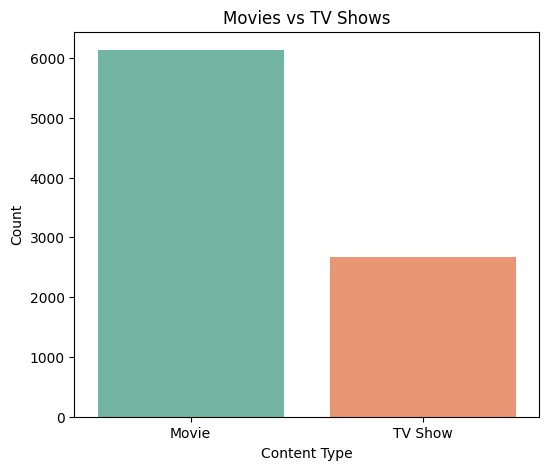

In [81]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='type', palette='Set2')

plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

/tmp/ipykernel_3661/176054087.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values,


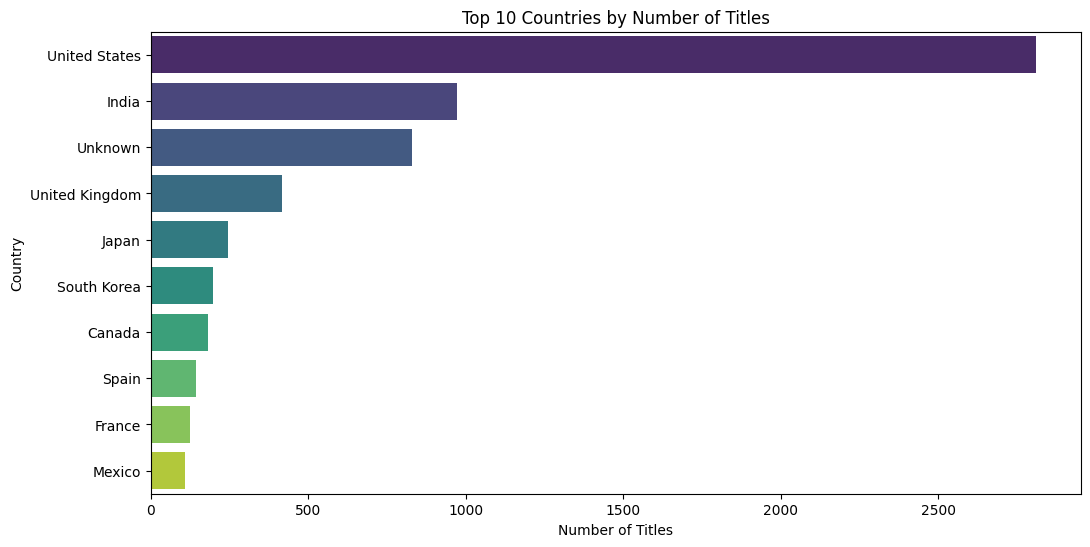

In [82]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_countries.values,
            y=top_countries.index,
            palette='viridis')

plt.title("Top 10 Countries by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

/tmp/ipykernel_3661/3349057593.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values,


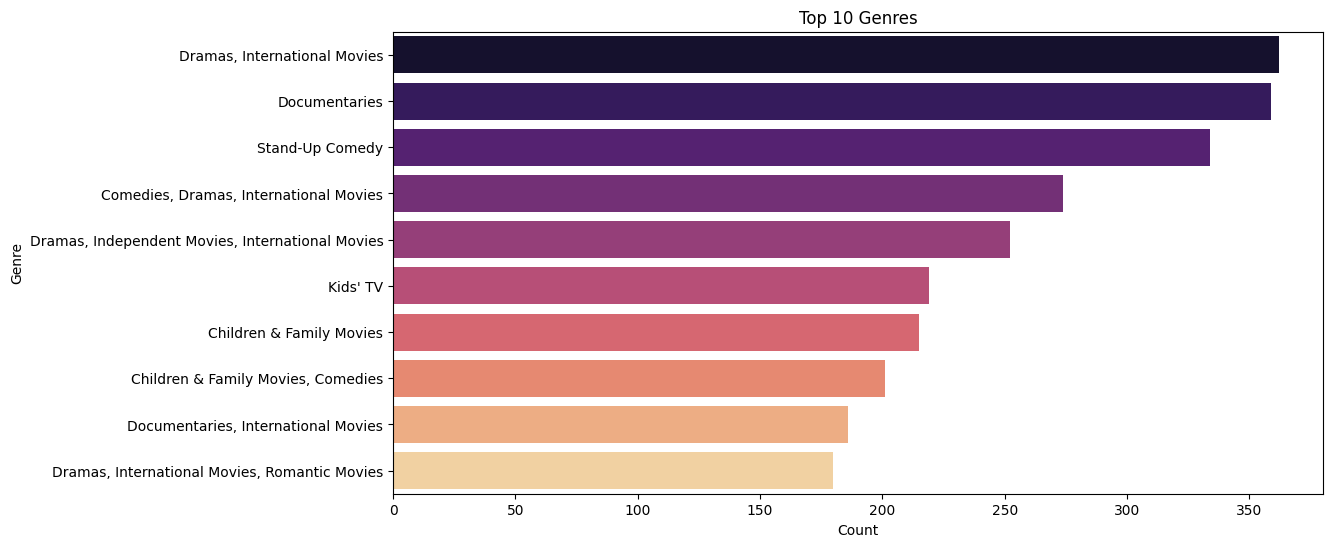

In [83]:
top_genres = df['listed_in'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_genres.values,
            y=top_genres.index,
            palette="magma")

plt.title("Top 10 Genres")
plt.xlabel("Count")
plt.ylabel("Genre")

plt.show()

/tmp/ipykernel_3661/3538832269.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


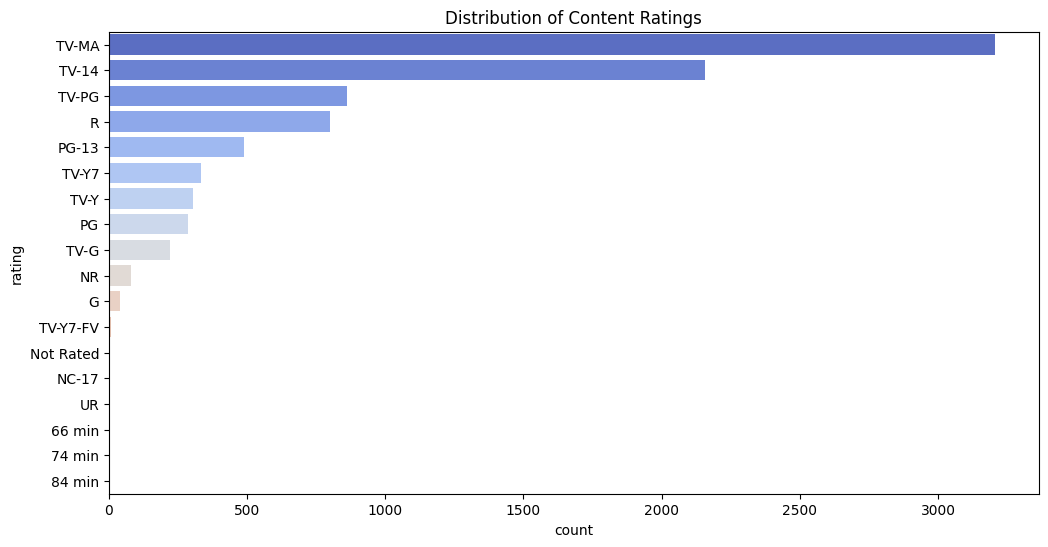

In [84]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='rating',
    order=df['rating'].value_counts().index,
    palette='coolwarm'
)

plt.title("Distribution of Content Ratings")

plt.show()

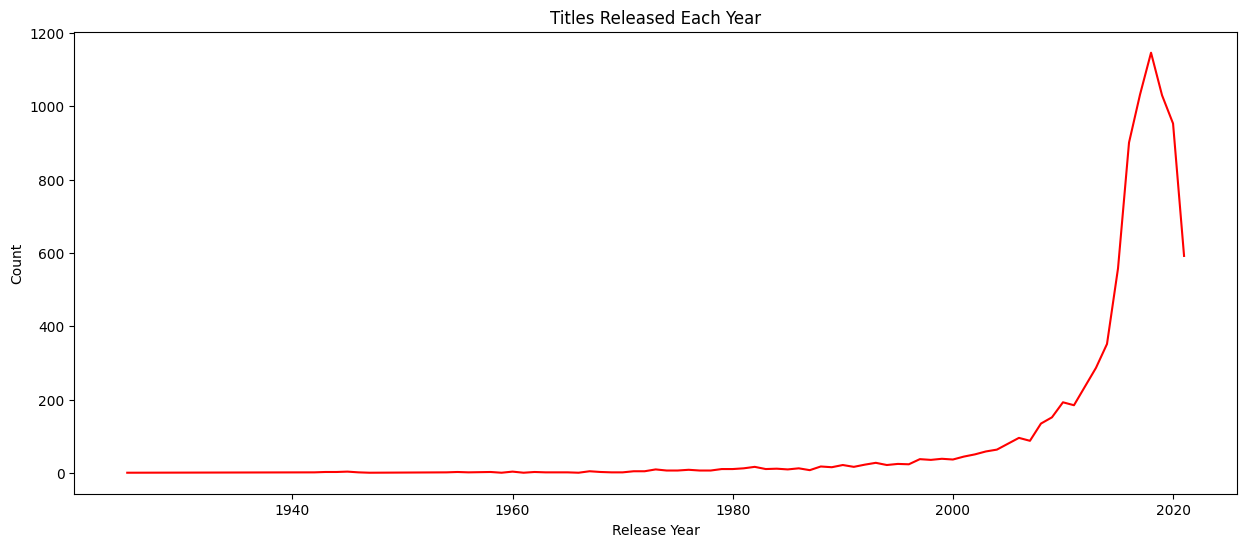

In [85]:
release = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(15,6))

plt.plot(release.index,
         release.values,
         color='red')

plt.title("Titles Released Each Year")
plt.xlabel("Release Year")
plt.ylabel("Count")

plt.show()

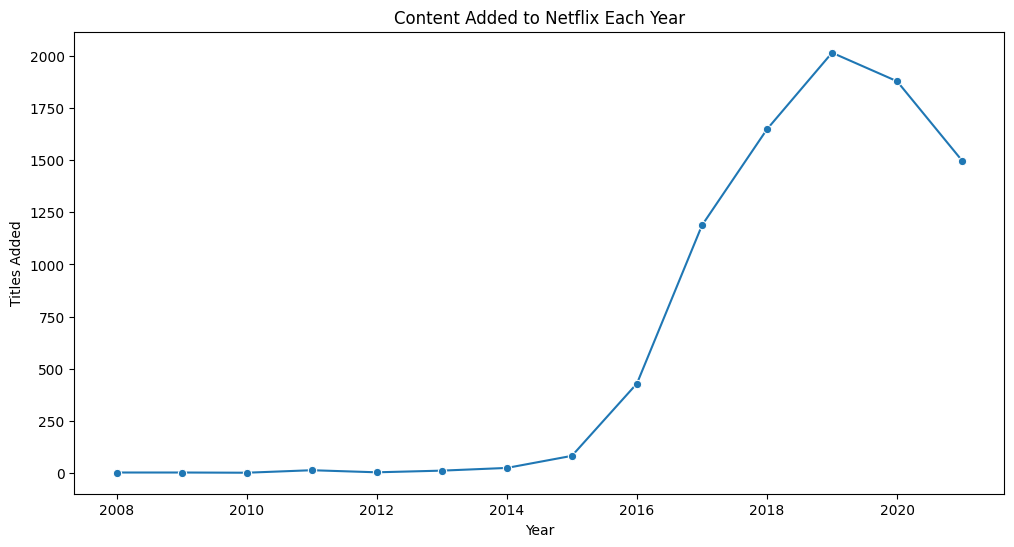

In [86]:
added = df['Year Added'].value_counts().sort_index()

plt.figure(figsize=(12,6))

sns.lineplot(
    x=added.index,
    y=added.values,
    marker='o'
)

plt.title("Content Added to Netflix Each Year")
plt.xlabel("Year")
plt.ylabel("Titles Added")

plt.show()

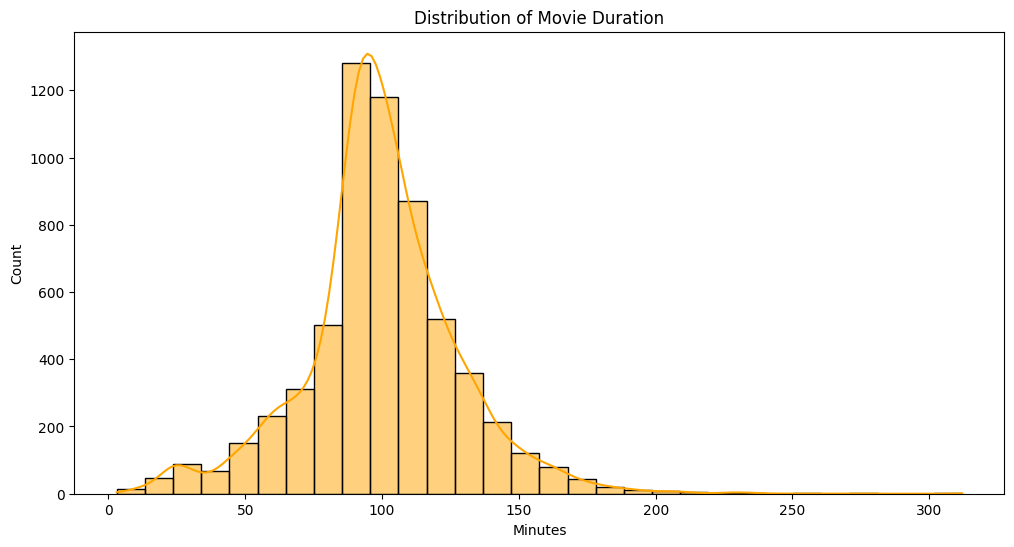

In [87]:
movies = df[df['Duration Unit']=='min']

plt.figure(figsize=(12,6))

sns.histplot(
    movies['Duration Value'],
    bins=30,
    kde=True,
    color='orange'
)

plt.title("Distribution of Movie Duration")
plt.xlabel("Minutes")

plt.show()

/tmp/ipykernel_3661/2225525486.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


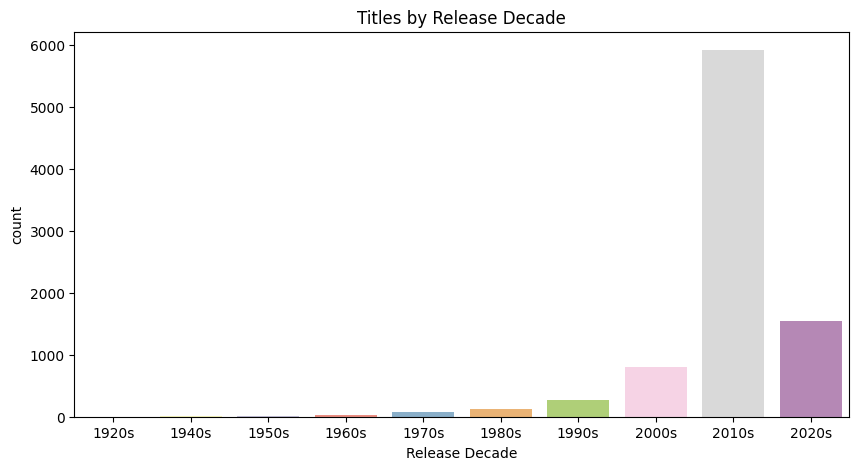

In [88]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Release Decade',
    order=sorted(df['Release Decade'].unique()),
    palette='Set3'
)

plt.title("Titles by Release Decade")

plt.show()

/tmp/ipykernel_3661/4194107668.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


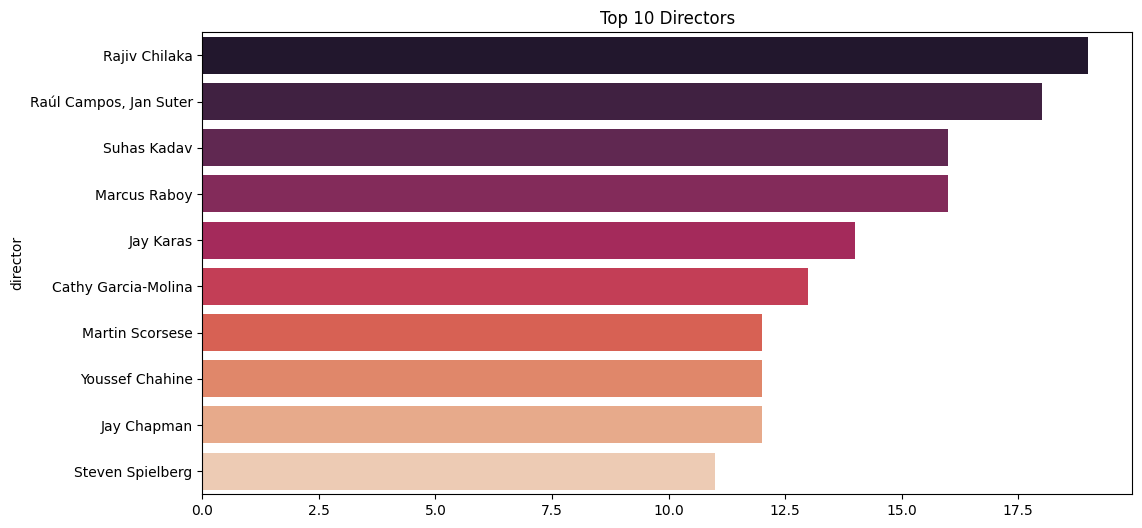

In [89]:
directors = (
    df[df['director'] != 'Unknown']['director']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=directors.values,
    y=directors.index,
    palette='rocket'
)

plt.title("Top 10 Directors")

plt.show()

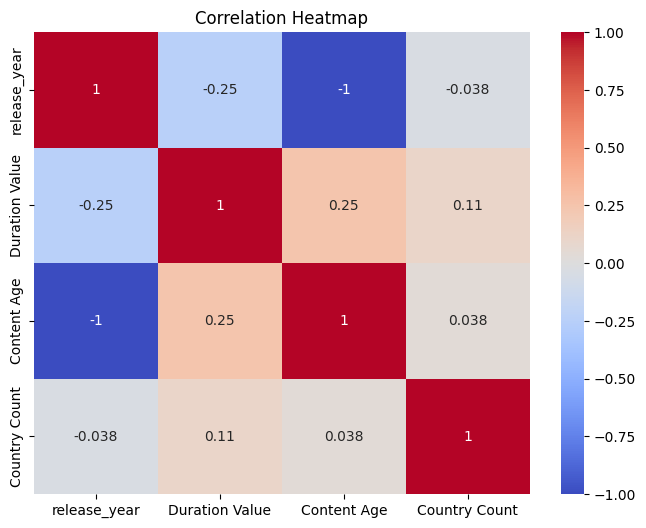

In [90]:
numeric = df[
    [
        'release_year',
        'Duration Value',
        'Content Age',
        'Country Count'
    ]
]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

/tmp/ipykernel_3661/1472210843.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


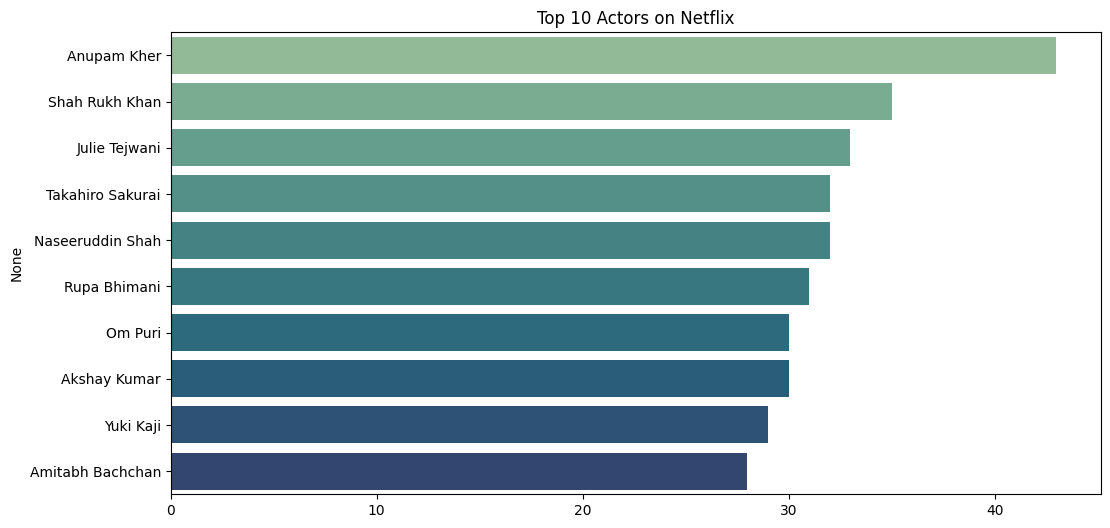

In [91]:
actors = (
    df[df['cast'] != 'Unknown']['cast']
    .str.split(',', expand=True)
    .stack()
    .str.strip()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=actors.values,
    y=actors.index,
    palette='crest'
)

plt.title("Top 10 Actors on Netflix")

plt.show()

In [92]:
df['country'].value_counts().head(10)

,count
country,
United States,2812
India,972
Unknown,830
United Kingdom,418
Japan,244
South Korea,199
Canada,181
Spain,145
France,124


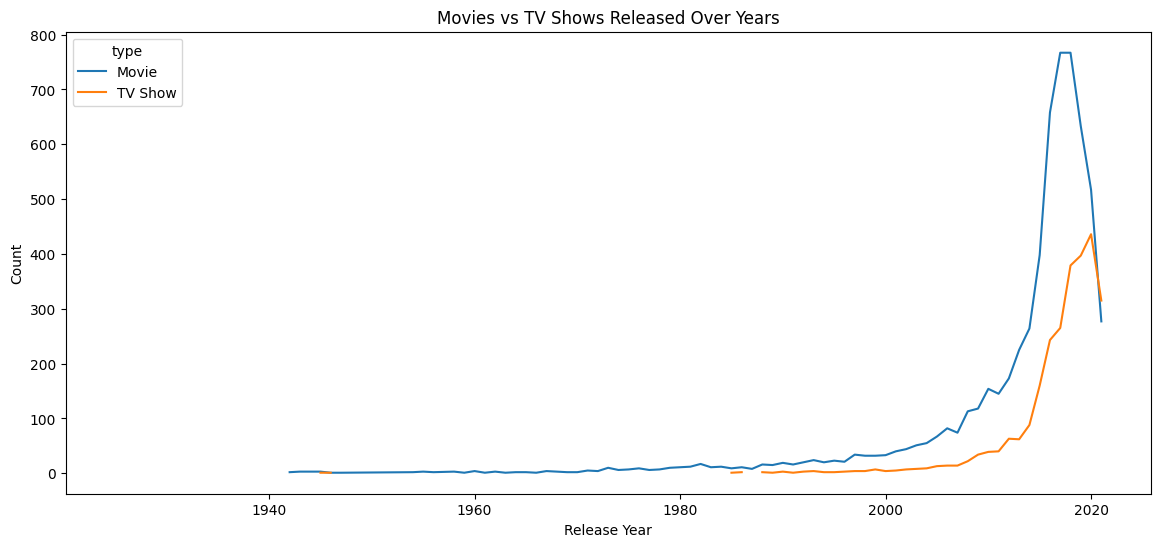

In [93]:
content = (
    df.groupby(['release_year', 'type']).size().unstack()
)

content.plot(figsize=(14,6))

plt.title("Movies vs TV Shows Released Over Years")
plt.xlabel("Release Year")
plt.ylabel("Count")

plt.show()

# Export Cleaned Dataset

In [96]:
df.to_csv("clean_netflix_titles1.csv", index=False)